# **EDA 1.0 NOTEBOOK**
by jack phelan ^_^

In [26]:
#imports
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df = pd.read_csv('../data/interim/1.0-initial-cleaned-data.csv', keep_default_na=False)

display(df.head())

,patient_id,age,gender,ethnicity,hospital_id,height_m,smoker,bmi,weight_kg,adjusted_weight_kg,has_diabetes,has_hypertension,exercise_frequency,diet_type,number_of_prior_visits,medications_prescribed,length_of_stay,type_of_treatment,target
0,1000000,23,Female,African American,Hosp2,1.6,False,25.0,64.0,63.283346,False,False,Regular,High-fat,3.0,3.0,0,None,0
1,1000002,56,Female,Hispanic,Hosp3,1.8,True,27.0,87.5,87.678859,False,False,Regular,High-fat,2.0,,2,None,0
2,1000003,28,Male,African American,Hosp1,1.8,False,35.0,113.4,113.497844,False,True,None,Other,,2.0,5,None,0
3,1000004,70,Female,Caucasian,Hosp2,1.8,False,27.7,89.7,89.717694,False,False,None,Other,3.0,,0,Major Surgery,0
4,1000005,48,Female,Hispanic,Hosp1,1.9,False,22.4,80.9,80.528927,False,False,Occasional,High-fat,7.0,5.0,7,Major Surgery,1


In [28]:
ids = df['patient_id']
target = df['target']

features_df = df.drop(columns=['target', 'patient_id'])

## **DISTRIBUTION/OUTLIERS ANALYSIS**

In [ ]:
# plots


def set_theme():
    sns.set_theme(
        style="whitegrid",
        context="talk",
        palette="flare",
        rc={
            "axes.titlesize": 14,
            "axes.labelsize": 12,
            "figure.dpi": 120,
        },
    )


"""
helper for formatting count-style plots (barplots, histograms with count stat, etc)
with consistent titles, axis labels, grid, and optional x-axis rotation for long category names
"""
def plot_formatting_helper(
    column_name,
    ax,
    title_suffix,
    y_label,
    rotate_x_threshold=None,
    n_items=None,
):
    pretty_name = column_name.replace("_", " ").title()
    ax.set_title(f"{pretty_name} {title_suffix}", pad=12, weight="bold")
    ax.set_xlabel(pretty_name)
    ax.set_ylabel(y_label)
    ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:,.0f}"))
    ax.grid(axis="y", alpha=0.25)
    sns.despine(ax=ax)

    if (
        rotate_x_threshold is not None
        and n_items is not None
        and n_items > rotate_x_threshold
    ):
        ax.tick_params(axis="x", rotation=35)


"""
make a histogram of a selected column (distribution)
options for bins, stat type (count, density, etc), kde overlay, and showing bin counts
"""
def plot_histogram(
    df,
    column_name,
    bins="auto",
    stat="count",
    kde=False,
    show_bin_counts=False,
    kde_color="#0f4c81",
    ax=None,
):
    created_fig = None
    if ax is None:
        created_fig, ax = plt.subplots(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=column_name,
        bins=bins,
        stat=stat,
        kde=kde,
        line_kws={"linewidth": 2},
        color=sns.color_palette("flare")[2],
        edgecolor="white",
        linewidth=1,
        alpha=0.9,
        ax=ax,
    )

    # Force KDE line styling after plot creation for consistent behavior.
    if kde and ax.lines:
        ax.lines[-1].set_color(kde_color)
        ax.lines[-1].set_linewidth(2.2)

    y_label = "Count" if stat == "count" else stat.title()
    plot_formatting_helper(
        column_name=column_name,
        ax=ax,
        title_suffix="Distribution",
        y_label=y_label,
    )
    ax.xaxis.set_major_formatter(mpl.ticker.ScalarFormatter())

    if show_bin_counts:
        for patch in ax.patches:
            height = patch.get_height()
            if height > 0:
                ax.annotate(
                    f"{height:,.0f}",
                    (patch.get_x() + patch.get_width() / 2, height),
                    ha="center",
                    va="bottom",
                    textcoords="offset points",
                    xytext=(0, 4),
                    fontsize=9,
                    color="#2f2f2f",
                )

    if created_fig is not None:
        created_fig.tight_layout()
        return created_fig, ax

    return ax.figure, ax


"""
make barplot of a selected column (value counts)
can optionally show bin counts, order by count, and choose color scheme
"""
def plot_barplot(
    df,
    column_name,
    show_bin_counts=True,
    top_n=None,
    order="desc",
    palette="flare",
    single_color=None,
    ax=None,
):
    plot_df = df.copy()

    # confirm column exists
    if column_name not in plot_df.columns:
        raise ValueError(f"Column '{column_name}' not found in dataframe")

    # get value counts of column for graphing
    val_counts = (
        plot_df[column_name]
        .astype("string")
        .fillna("Missing")
        .value_counts(dropna=False)
        .rename_axis(column_name)
        .reset_index(name="count")
    )

    # optional order of value counts
    if order == "asc":
        val_counts = val_counts.sort_values("count", ascending=True)
    else:
        val_counts = val_counts.sort_values("count", ascending=False)

    if top_n is not None:
        val_counts = val_counts.head(top_n)

    created_fig = None
    if ax is None:
        created_fig, ax = plt.subplots(figsize=(8, 5))

    sns.barplot(
        data=val_counts,
        x=column_name,
        y="count",
        color=single_color if single_color is not None else "#9f86c0",
        edgecolor="white",
        linewidth=1,
        ax=ax,
    )

    # Apply one color per bar from the chosen palette.
    if single_color is None:
        bar_colors = sns.color_palette(palette, n_colors=len(ax.patches))
        for patch, color in zip(ax.patches, bar_colors):
            patch.set_facecolor(color)

    # call helper to make the graph look nicer
    plot_formatting_helper(
        column_name=column_name,
        ax=ax,
        title_suffix="Counts",
        y_label="Count",
        rotate_x_threshold=8,
        n_items=len(val_counts),
    )

    # add bin counts if declared
    if show_bin_counts:
        for patch in ax.patches:
            height = patch.get_height()
            if height > 0:
                ax.annotate(
                    f"{height:,.0f}",
                    (patch.get_x() + patch.get_width() / 2, height),
                    ha="center",
                    va="bottom",
                    textcoords="offset points",
                    xytext=(0, 4),
                    fontsize=9,
                    color="#2f2f2f",
                )

    if created_fig is not None:
        created_fig.tight_layout()
        return created_fig, ax

    return ax.figure, ax

""" 
generic function for creaitng a grid of subplots based on the implemented individual plot functions
"""
def plot_grid(
    df,
    column_names,
    plot_func,
    n_plot_cols=2,
    sharex=False,
    sharey=False,
    figsize_scale=(8, 5),
    **plot_kwargs,
):
    """Generic grid renderer for any plotting function that accepts df, column_name, and ax."""
    n_plots = len(column_names)
    n_rows = (n_plots - 1) // n_plot_cols + 1

    fig, axes = plt.subplots(
        n_rows,
        n_plot_cols,
        figsize=(figsize_scale[0] * n_plot_cols, figsize_scale[1] * n_rows),
        sharex=sharex,
        sharey=sharey,
    )

    axes = np.array(axes).reshape(-1)

    for i, column_name in enumerate(column_names):
        plot_func(
            df=df,
            column_name=column_name,
            ax=axes[i],
            **plot_kwargs,
        )

    for j in range(n_plots, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout()
    return fig, axes[:n_plots]


def plot_barplot_grid(
    df,
    column_names,
    show_bin_counts=True,
    top_n=None,
    order="desc",
    palette="flare",
    single_color=None,
    n_plot_cols=2,
    sharey=False,
):
    """Backwards-compatible wrapper around the generic plot_grid for barplots."""
    return plot_grid(
        df=df,
        column_names=column_names,
        plot_func=plot_barplot,
        n_plot_cols=n_plot_cols,
        sharey=sharey,
        show_bin_counts=show_bin_counts,
        top_n=top_n,
        order=order,
        palette=palette,
        single_color=single_color,
    )

(<Figure size 2880x3000 with 14 Axes>,
 array([<Axes: title={'center': 'Hospital Id Counts'}, xlabel='Hospital Id', ylabel='Count'>,
        <Axes: title={'center': 'Gender Counts'}, xlabel='Gender', ylabel='Count'>,
        <Axes: title={'center': 'Smoker Counts'}, xlabel='Smoker', ylabel='Count'>,
        <Axes: title={'center': 'Has Diabetes Counts'}, xlabel='Has Diabetes', ylabel='Count'>,
        <Axes: title={'center': 'Has Hypertension Counts'}, xlabel='Has Hypertension', ylabel='Count'>,
        <Axes: title={'center': 'Exercise Frequency Counts'}, xlabel='Exercise Frequency', ylabel='Count'>,
        <Axes: title={'center': 'Diet Type Counts'}, xlabel='Diet Type', ylabel='Count'>,
        <Axes: title={'center': 'Number Of Prior Visits Counts'}, xlabel='Number Of Prior Visits', ylabel='Count'>,
        <Axes: title={'center': 'Medications Prescribed Counts'}, xlabel='Medications Prescribed', ylabel='Count'>,
        <Axes: title={'center': 'Length Of Stay Counts'}, xlabel='Len

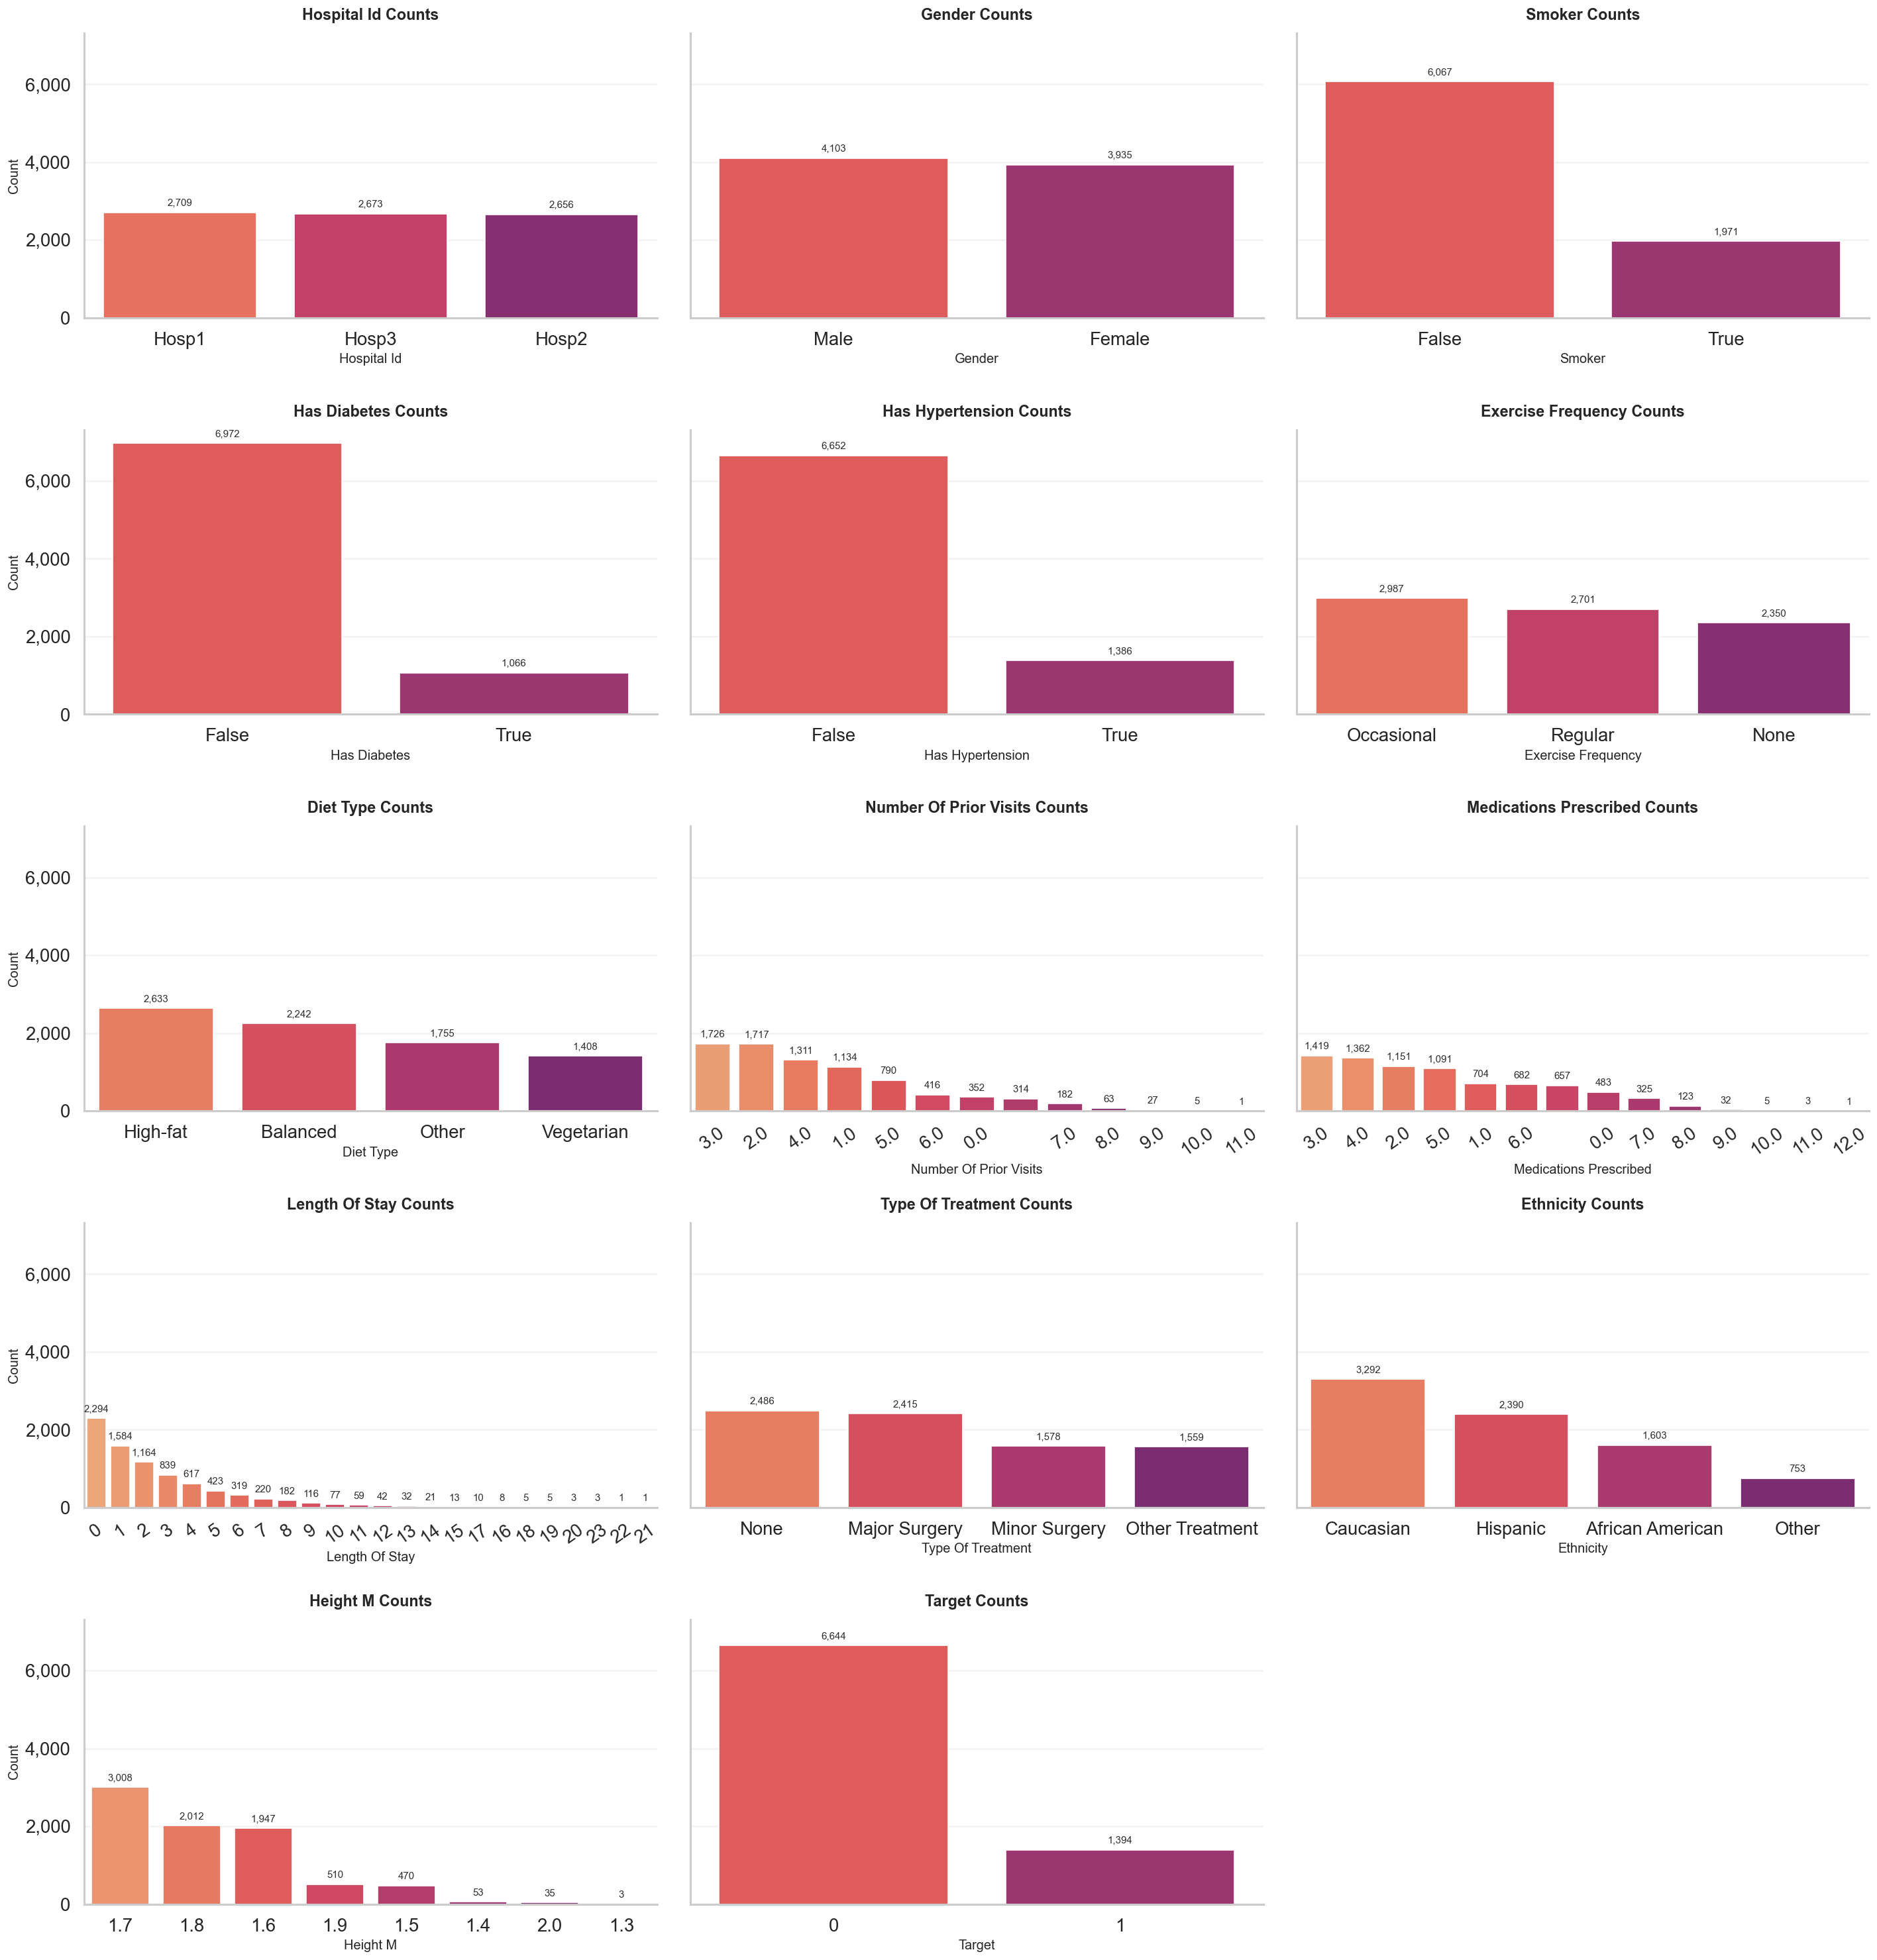

In [44]:
set_theme()

categories = [
    "hospital_id",
    "gender",
    "smoker",
    "has_diabetes",
    "has_hypertension",
    "exercise_frequency",
    "diet_type",
    "number_of_prior_visits",
    "medications_prescribed",
    "length_of_stay",
    "type_of_treatment",
    "ethnicity",
    "height_m",
    "target"
]

plot_grid(
    df=df,
    column_names=categories,
    plot_func=plot_barplot,
    palette="flare",
    n_plot_cols=3,
    sharey=True,
)

(<Figure size 1920x1200 with 4 Axes>,
 array([<Axes: title={'center': 'Bmi Distribution'}, xlabel='Bmi', ylabel='Count'>,
        <Axes: title={'center': 'Weight Kg Distribution'}, xlabel='Weight Kg', ylabel='Count'>,
        <Axes: title={'center': 'Adjusted Weight Kg Distribution'}, xlabel='Adjusted Weight Kg', ylabel='Count'>,
        <Axes: title={'center': 'Age Distribution'}, xlabel='Age', ylabel='Count'>],
       dtype=object))

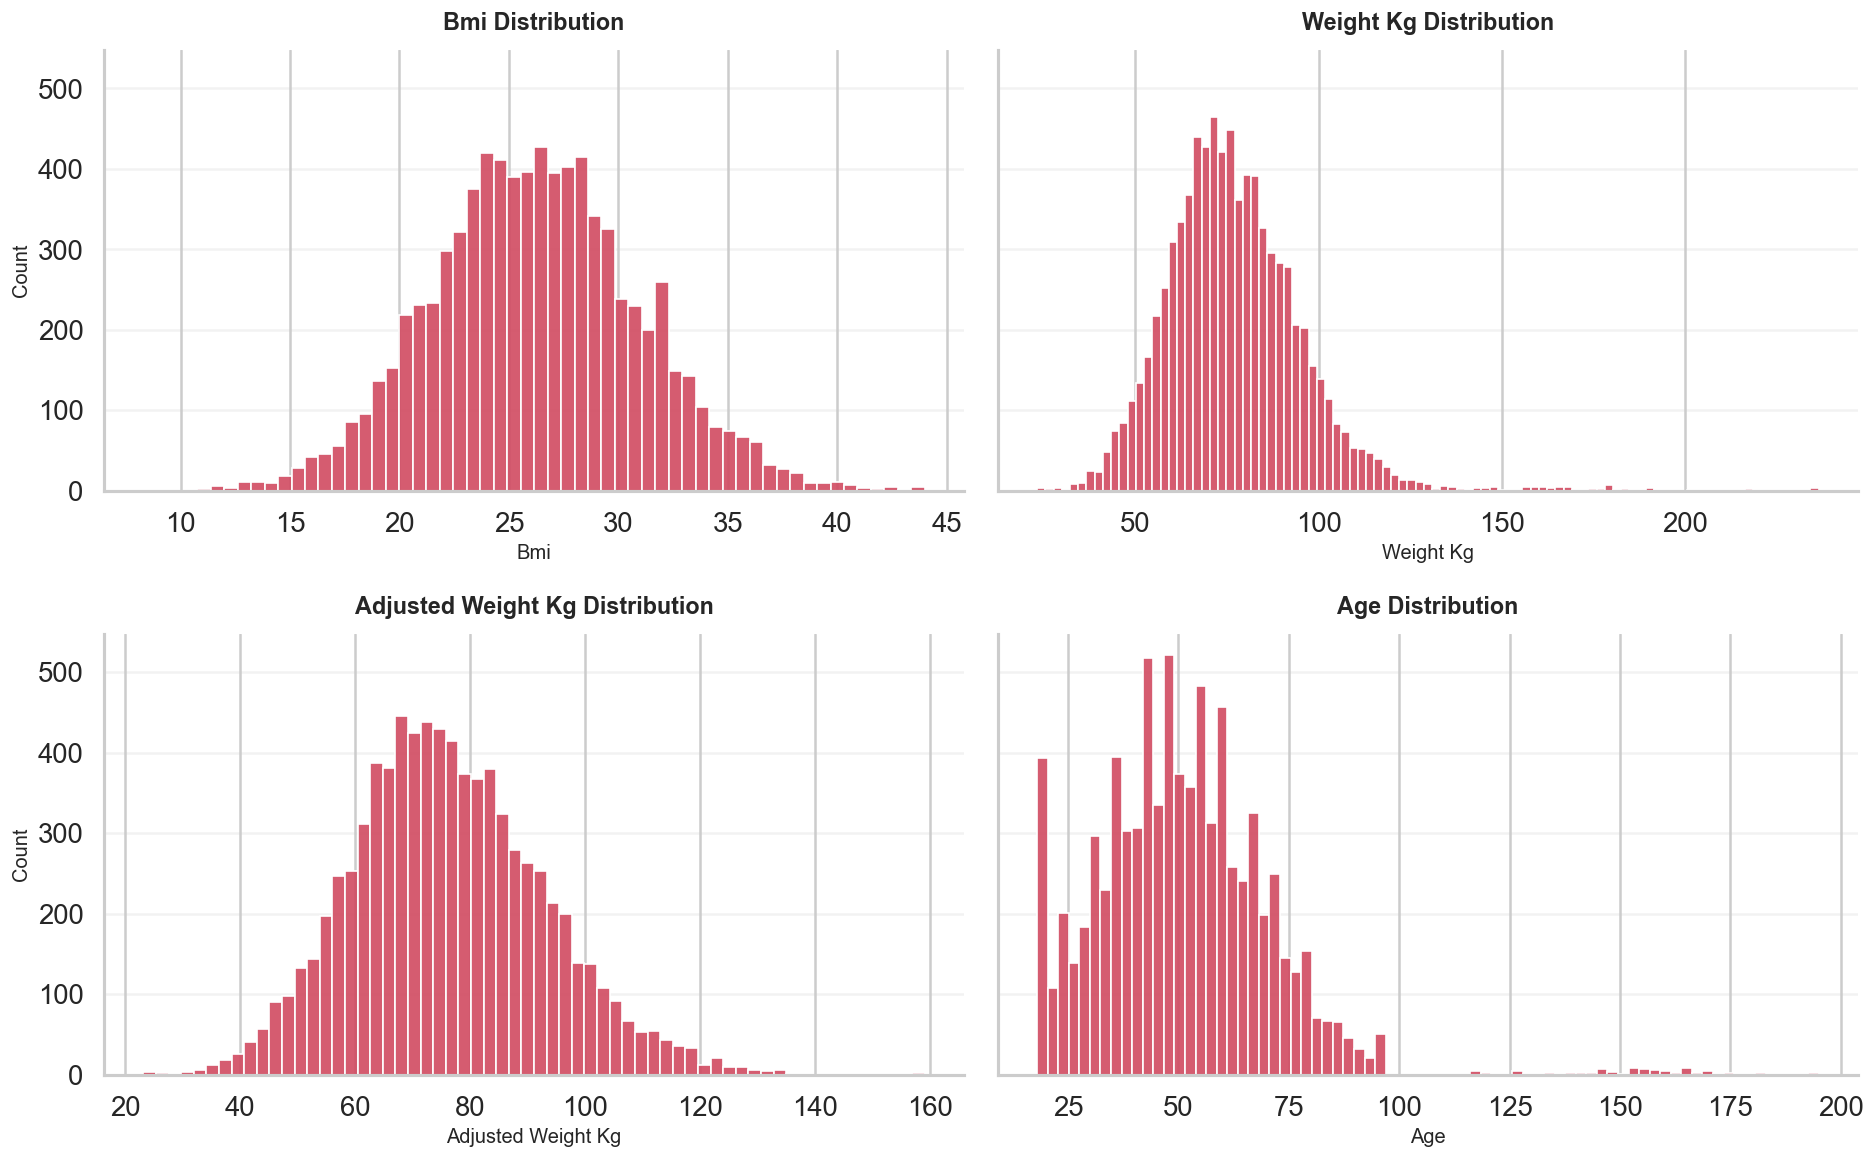

In [41]:
set_theme()

measure_cols = ["bmi", "weight_kg", "adjusted_weight_kg", "age"]

plot_grid(
    df=df,
    column_names=measure_cols,
    plot_func=plot_histogram,
    n_plot_cols=2,
    sharey=True, 
    bins="auto",
    stat="count",
    kde=False,
    show_bin_counts=False,
)